In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import cv2

In [3]:
# Constants
ORIGINAL_SIZE = (120, 224) 
TARGET_SIZE = (224, 224)  
DATA_PATH = 'sorted_images'  
OUTPUT_CATEGORIES = os.listdir(DATA_PATH)  
OUTPUT_SHAPE = len(OUTPUT_CATEGORIES)  

In [4]:
def pad_image(img, target_size):
    padded_img = cv2.copyMakeBorder(
        img, 
        (target_size[0] - img.shape[0]) // 2, 
        (target_size[0] - img.shape[0]) // 2,
        (target_size[1] - img.shape[1]) // 2, 
        (target_size[1] - img.shape[1]) // 2,
        cv2.BORDER_CONSTANT, value=[0, 0, 0]
    )
    return padded_img

In [5]:
data = []
labels = []

In [6]:
for category in OUTPUT_CATEGORIES:
    category_path = os.path.join(DATA_PATH, category)
    label = OUTPUT_CATEGORIES.index(category)  # Encode category as integer
    for img_name in tqdm(os.listdir(category_path)):
        img_path = os.path.join(category_path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            img = pad_image(img, TARGET_SIZE)  # Resize and pad image
            img = img / 255.0  # Normalize
            data.append(img)
            labels.append(label)

100%|██████████| 1915/1915 [00:09<00:00, 192.98it/s]


In [7]:
data = np.array(data, dtype=np.float32)
labels = np.array(labels)

Categories: ['Good', 'Hazardous', 'Moderate', 'Unhealthy', 'Unhealthy for Sensitive Groups', 'Very Unhealthy']


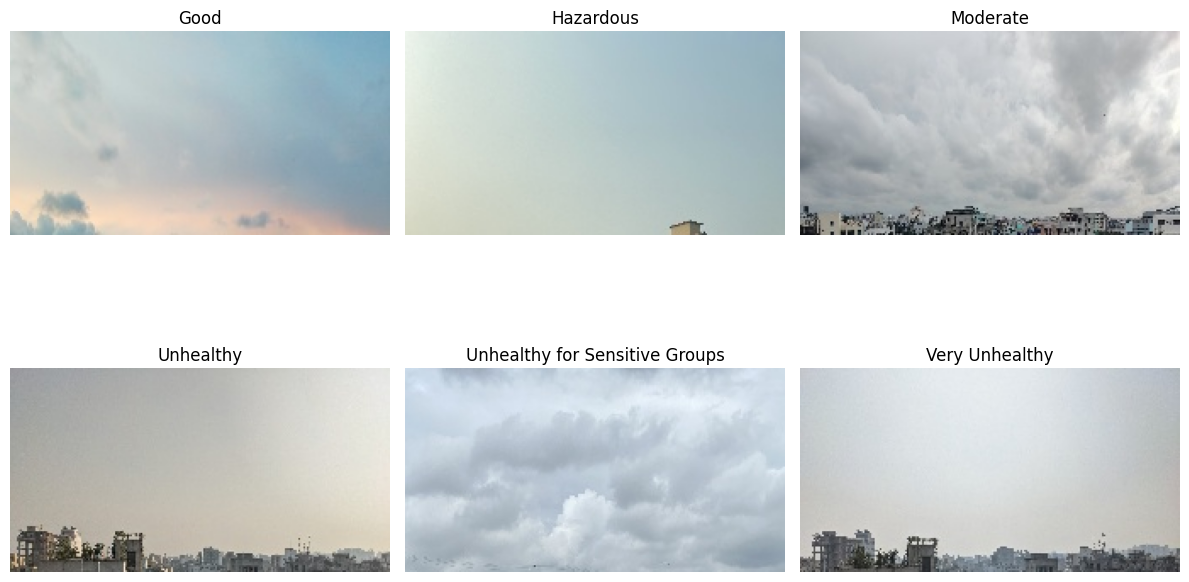

In [27]:
import matplotlib.pyplot as plt
import os
from PIL import Image

# Path to the dataset directory
dataset_path = 'sorted_images/'  # Replace with your dataset path

# List categories (subfolders in the dataset directory)
categories = os.listdir(dataset_path)
print("Categories:", categories)

# Display a few images from each category
plt.figure(figsize=(12, 8))

for i, category in enumerate(categories[:6]):  # Display images from up to 6 categories
    category_path = os.path.join(dataset_path, category)
    
    # Get a list of image files in the category
    image_files = [f for f in os.listdir(category_path) if f.endswith(('jpg', 'jpeg', 'png'))]
    
    if image_files:
        # Load the first image in the category
        image_path = os.path.join(category_path, image_files[0])
        img = Image.open(image_path)
        
        # Add the image to the plot
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(category)
        plt.axis('off')

plt.tight_layout()
plt.show()


In [8]:
x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42) 

In [9]:
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [10]:
x = base_model.output #features extract
x = Flatten()(x)
x = Dense(256, activation='relu')(x) #fully
x = Dropout(0.5)(x) #to overfitting
x = Dense(OUTPUT_SHAPE, activation='softmax')(x)  #fully connected class

NameError: name 'model' is not defined

In [12]:
model = Model(inputs=base_model.input, outputs=x)

#layers freeze
for layer in base_model.layers:
    layer.trainable = False

In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             

 Total params: 26,448,710 (100.89 MB)

 Trainable params: 6,424,326 (24.51 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

In [ ]:
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    validation_data=(x_test, y_test),
    epochs=20,
    steps_per_epoch=len(x_train) // 32,
    verbose=1
)

Found 4849 images belonging to 6 classes.
Found 536 images belonging to 6 classes.


In [ ]:
for layer in base_model.layers[-10:]:
    layer.trainable = True

C:\Users\sehra\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
 74/151 ━━━━━━━━━━━━━━━━━━━━ 2:17 2s/step - accuracy: 0.2795 - loss: 2.0442

KeyboardInterrupt: 

In [16]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [17]:
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    validation_data=(x_test, y_test),
    epochs=10,
    steps_per_epoch=len(x_train) // 32,
    verbose=1
)

Epoch 1/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 874s 7s/step - accuracy: 0.4512 - loss: 1.2536 - val_accuracy: 0.5190 - val_loss: 1.0006
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 104s 739ms/step - accuracy: 0.4062 - loss: 1.2395 - val_accuracy: 0.5181 - val_loss: 1.0040
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 877s 7s/step - accuracy: 0.4970 - loss: 1.1824 - val_accuracy: 0.5274 - val_loss: 1.0127
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 108s 771ms/step - accuracy: 0.4062 - loss: 1.3902 - val_accuracy: 0.5460 - val_loss: 1.0020
Epoch 5/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 1297s 10s/step - accuracy: 0.5198 - loss: 1.1340 - val_accuracy: 0.6110 - val_loss: 0.9446
Epoch 6/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 103s 737ms/step - accuracy: 0.5938 - loss: 0.9441 - val_accuracy: 0.6128 - val_loss: 0.9361
Epoch 7/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 1156s 9s/step - accuracy: 0.5669 - loss: 1.0267 - val_accuracy: 0.6648 - val_loss: 0.8542
Epoch 8/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 124s 881ms/step - accuracy: 0.6250 - loss: 0.

In [18]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

34/34 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step - accuracy: 0.7047 - loss: 0.8049
Test Accuracy: 71.03%


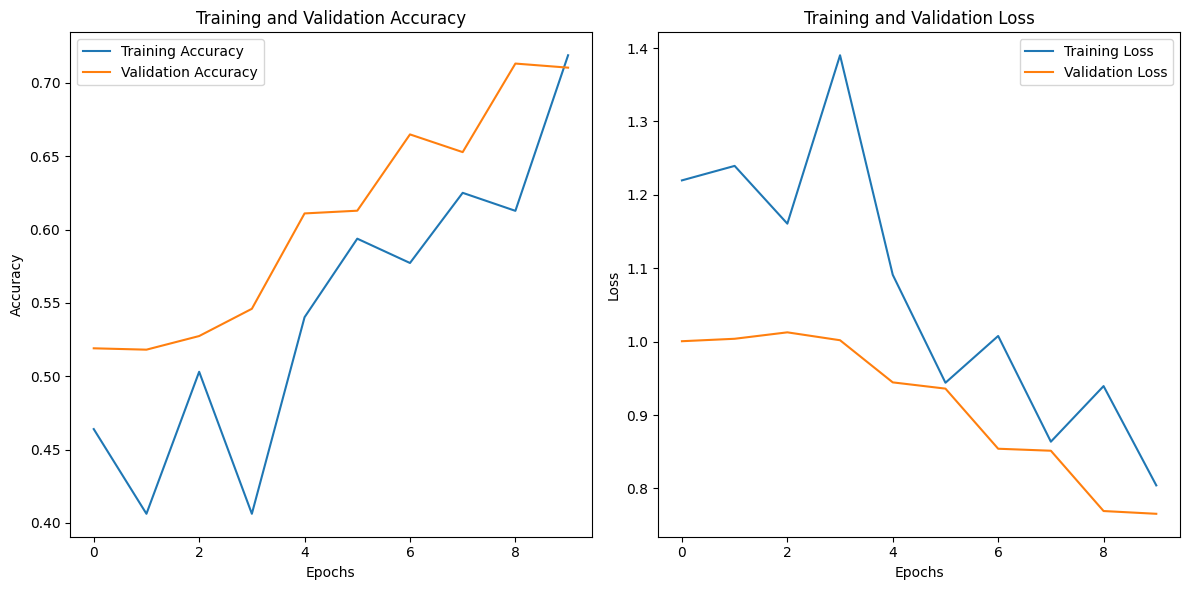

In [20]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()
